# CME Futures: Strategy Analysis

The four preceding notebooks each produced a registered, complete population of validation
backtests: the equal-weight signal baseline over every model configuration and checkpoint, the
alternative allocators over the signal shortlist, the transaction-cost grid, and the position-risk
overlays. This notebook reads those registered results and names one case-study configuration
from them.

A case-study configuration is a model configuration - family, settings, and the training
checkpoint the predictions came from - together with the signal, sizing, and risk rules applied to
it. The configuration with the highest validation Sharpe across the signal, allocation, and
risk-overlay stages is the one selected. Cost-sensitivity backtests vary the friction assumption
on a configuration already chosen, so they describe it rather than compete with it and are not in
the pool.

Both return horizons are selected from together. The horizon is part of the configuration, so it
is read off the row that wins rather than fixed before looking.

The holdout period is a later date range that no notebook up to this point has touched. It is
evaluated on the selected configuration alone, one time, and it may disagree with the validation
result. That disagreement is an outcome to report, not a reason to select again.

Prerequisites: `13_backtest`, `14_portfolio_management`, `15_costs`, and `16_risk_management`.

In [1]:
"""Select and describe one CME futures case-study configuration."""

import plotly.express as px
import polars as pl

from case_studies.cme_futures.research_workflow import (
    ALL_LABELS,
    final_selection_candidate_set,
    final_validation_candidate_set,
    final_validation_results,
    holdout_evidence,
    open_study,
    product_universe_table,
    rank_by_validation_sharpe,
    selection_catalog,
)
from case_studies.research import OfficialPopulation, Result
from utils.style import COLORS

In [2]:
EXECUTION_TIER = "canonical"
WORKSPACE: str | None = None
PREVIEW_LABELS: list[str] = []

## The pool the configuration is selected from

Each per-label pool opens the three stage populations and fails if any member is missing,
incomplete, or produced under a preview identity. Combining the two horizons into one immutable
set records exactly which results were compared, so the selection can be repeated later against
the same members rather than against whatever the registry holds at the time.

In [3]:
study = open_study(execution_tier=EXECUTION_TIER, workspace=WORKSPACE)
if EXECUTION_TIER == "canonical":
    if PREVIEW_LABELS:
        raise ValueError("canonical execution cannot declare preview reductions")
    labels = ALL_LABELS
elif EXECUTION_TIER == "preview":
    if WORKSPACE is None or not PREVIEW_LABELS:
        raise ValueError("preview execution requires WORKSPACE and PREVIEW_LABELS")
    unknown = sorted(set(PREVIEW_LABELS) - set(ALL_LABELS))
    if unknown:
        raise ValueError(f"preview labels this case study does not declare: {unknown}")
    labels = tuple(PREVIEW_LABELS)
else:
    raise ValueError(f"unsupported execution tier: {EXECUTION_TIER!r}")
universe = product_universe_table()
universe

sector,product,expiry_rule,contract_months
str,str,str,str
"""agriculture""","""ZC""","""business_day_before_15th""","""H,K,N,U,Z"""
"""agriculture""","""ZL""","""business_day_before_15th""","""F,H,K,N,Q,U,V,Z"""
"""agriculture""","""ZM""","""business_day_before_15th""","""F,H,K,N,Q,U,V,Z"""
"""agriculture""","""ZS""","""business_day_before_15th""","""F,H,K,N,Q,U,X"""
"""agriculture""","""ZW""","""business_day_before_15th""","""H,K,N,U,Z"""
…,…,…,…
"""metals""","""SI""","""3rd_last_business_day""","""H,K,N,U,Z"""
"""treasuries""","""ZB""","""last_business_day""","""H,M,U,Z"""
"""treasuries""","""ZF""","""last_business_day""","""H,M,U,Z"""


Only a canonical pool is an immutable set. A preview run publishes no candidate set - one cannot
hold a preview member - so its pool is the rows its own reduced execution produced and the
`candidate_set_hash` column below is null. Everything downstream, the ranking rule included, is
the same either way; what differs is whether the pool can be reopened later by name.

In [4]:
if EXECUTION_TIER == "canonical":
    per_label = {label: final_validation_candidate_set(study, label=label) for label in labels}
    per_label_results = {
        label: tuple(Result.open(study, value) for value in pool_set.members)
        for label, pool_set in per_label.items()
    }
    candidates = final_selection_candidate_set(study)
    pool_results = tuple(Result.open(study, value) for value in candidates.members)
    pool_identity = candidates.hash
    per_label_identity = {label: pool_set.hash for label, pool_set in per_label.items()}
else:
    per_label_results = {
        label: final_validation_results(study, label=label, execution_tier=EXECUTION_TIER)
        for label in labels
    }
    pool_results = tuple(result for results in per_label_results.values() for result in results)
    pool_identity = None
    per_label_identity = dict.fromkeys(labels)
pool = selection_catalog(study, (result.hash for result in pool_results))
pool_size = pl.DataFrame(
    [
        {
            "label": label,
            "candidates": len(results),
            "candidate_set_hash": per_label_identity[label],
        }
        for label, results in per_label_results.items()
    ],
    schema={"label": pl.String, "candidates": pl.Int64, "candidate_set_hash": pl.String},
).sort("label")

In [5]:
pool_size

label,candidates,candidate_set_hash
str,i64,str
"""fwd_ret_21d""",570,"""f9e60e6a8e5c"""
"""fwd_ret_5d""",570,"""2bf838b626e9"""


## What each selection stage contributed

The three stages run in sequence, each on the survivors of the one before. The signal stage
carries every configuration and checkpoint at equal weight. Allocation runs on the strongest
distinct configurations from that stage, and the risk overlay on the strongest result so far for
each horizon. Later stages therefore hold far fewer candidates than the first, and the spread
within a stage shows how much of the outcome the sizing and risk rules decide once the model is
fixed.

**The medians cannot be read across stages.** Each stage runs on the survivors of the one before,
chosen on the same validation Sharpe the table reports, so the pool shrinks from 496 to 60 to 14
by selecting on the quantity being summarized. On `fwd_ret_21d` the median rises from -0.392 to
0.192 to 1.010 along that shrinking pool, and almost all of that movement is the selection, not
the allocators or the risk rules. What the stages do support is the comparison within a row: the
fourteen risk overlays share one model, one signal, and one sizing rule, and they still span
0.322 to 1.274, which is the range the position rule alone is responsible for.

In [6]:
stage_summary = (
    pool.group_by("label", "stage")
    .agg(
        pl.len().alias("candidates"),
        pl.col("sharpe").min().alias("min_sharpe"),
        pl.col("sharpe").median().alias("median_sharpe"),
        pl.col("sharpe").max().alias("max_sharpe"),
    )
    .sort("label", "stage")
)

In [7]:
stage_summary

label,stage,candidates,min_sharpe,median_sharpe,max_sharpe
str,str,u32,f64,f64,f64
"""fwd_ret_21d""","""allocation""",60,-0.29416,0.192124,1.138895
"""fwd_ret_21d""","""risk_overlay""",14,0.321874,1.009729,1.27421
"""fwd_ret_21d""","""signal""",496,-1.042364,-0.391721,1.044776
"""fwd_ret_5d""","""allocation""",60,-0.736674,0.419389,0.715717
"""fwd_ret_5d""","""risk_overlay""",14,0.427838,0.736625,1.235576
"""fwd_ret_5d""","""signal""",496,-0.908679,0.063778,0.623463


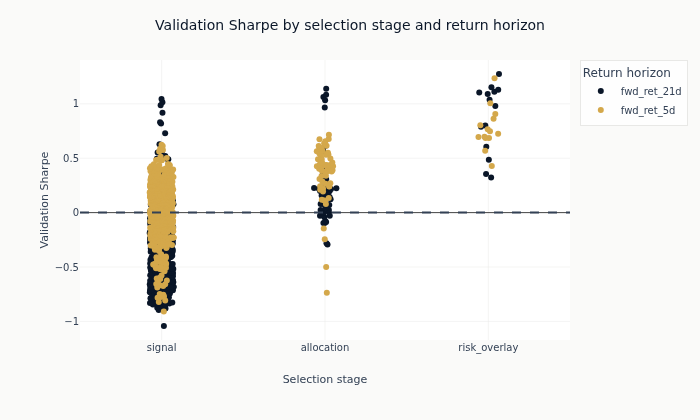

In [8]:
fig = px.strip(
    pool.to_pandas(),
    x="stage",
    y="sharpe",
    color="label",
    stripmode="overlay",
    category_orders={"stage": ["signal", "allocation", "risk_overlay"]},
    color_discrete_sequence=[COLORS["blue"], COLORS["amber"]],
    labels={"stage": "Selection stage", "sharpe": "Validation Sharpe", "label": "Return horizon"},
)
fig.update_layout(
    title="Validation Sharpe by selection stage and return horizon",
    height=420,
)
fig.add_hline(y=0, line_dash="dash", line_color=COLORS["neutral"])
fig.show()

## The selected configuration

`best_validation_sharpe` ranks the immutable set by Sharpe and breaks a tie on the backtest
identity, so the same pool always names the same row. The prediction checkpoint is part of that
identity: two rows from the same trained model at different checkpoints are different
configurations. A holdout matched on the trained model alone can therefore land on a different
checkpoint from the one selected, and report a different result for what looks like the same
model, which is why the checkpoint travels with the selection into the lock below.

In [9]:
selected = rank_by_validation_sharpe(study, pool_results)[0]
selected_row = pool.filter(pl.col("backtest_hash") == selected.hash)
selected_label = selected_row.item(0, "label")
selected_strategy = selected.spec()["strategy"]

In [10]:
selected_row

label,family,config_name,checkpoint_kind,checkpoint_value,stage,signal_method,allocation_method,risk_method,sharpe,max_drawdown,num_trades,avg_turnover,complete,training_hash,prediction_hash,backtest_hash
str,str,str,str,i64,str,str,str,str,f64,f64,f64,f64,bool,str,str,str
"""fwd_ret_21d""","""latent_factors""","""sdf""","""epoch""",1280,"""risk_overlay""","""equal_weight_top_k""","""inverse_vol""",null,1.27421,-0.094738,1357.0,0.120486,true,"""52973301b456""","""206874caf483""","""99eb738f0181"""


In [11]:
pl.DataFrame(
    [
        {
            "candidate_set_hash": pool_identity,
            "candidates_compared": len(pool_results),
            "label": selected_label,
            "signal": str(selected_strategy["signal"]),
            "allocation": str(selected_strategy.get("allocation")),
            "risk": str(selected_strategy.get("risk")),
        }
    ]
)

candidate_set_hash,candidates_compared,label,signal,allocation,risk
str,i64,str,str,str,str
"""ea345c48b053""",1140,"""fwd_ret_21d""","""{'long_short': True, 'method':…","""{'long_short': True, 'method':…","""{'position_rules': [{'bars': 2…"


## What friction costs this configuration

The cost grid was run on the per-horizon leader of the signal and allocation stages, holding the
model, sizing, and contract specification fixed and varying only the all-in cost assumption.
Commission and slippage each take half of the quoted figure. The curve for the selected horizon
shows how the validation result changes as the assumed fill gets worse.

In [12]:
if EXECUTION_TIER == "canonical":
    cost_population = OfficialPopulation.one(study, name="cme_futures-cost-validation-v1")
    cost_members = list(cost_population.require_complete())
else:
    cost_members = (
        study.backtests.table(include_preview=True)
        .filter(
            (pl.col("execution_tier") == "preview")
            & (pl.col("stage") == "cost_sensitivity")
            & pl.col("complete")
        )
        .get_column("backtest_hash")
        .to_list()
    )
cost_curve = (
    study.backtests.table(include_preview=True)
    .filter(pl.col("backtest_hash").is_in(cost_members) & (pl.col("label") == selected_label))
    .with_columns(
        (
            pl.col("spec_json")
            .str.json_path_match("$.decision_artifact.parameters.costs.commission_bps")
            .cast(pl.Float64)
            + pl.col("spec_json")
            .str.json_path_match("$.decision_artifact.parameters.costs.slippage_bps")
            .cast(pl.Float64)
        ).alias("total_cost_bps")
    )
    .select("total_cost_bps", "sharpe", "total_return", "num_trades", "backtest_hash")
    .sort("total_cost_bps")
)
if cost_curve.is_empty():
    raise RuntimeError(f"the cost population contains no member for {selected_label!r}")
# `json_path_match` returns null for a path that is not in the document rather than raising, and
# null + null is null, so reading the grid value from the wrong place yields a full-height frame
# whose cost axis is entirely missing. The emptiness check above passes on such a frame and the
# curve below plots against nothing. Refuse it here instead.
if cost_curve.get_column("total_cost_bps").null_count():
    raise RuntimeError(
        "cost members record no all-in cost at "
        "$.decision_artifact.parameters.costs; the cost curve has no axis"
    )

In [13]:
cost_curve

total_cost_bps,sharpe,total_return,num_trades,backtest_hash
f64,f64,f64,f64,str
0.0,1.208601,0.815608,1204.0,"""6748dc719115"""
1.0,1.201921,0.808679,1202.0,"""1b773b08bca3"""
2.0,1.175391,0.786478,1204.0,"""f26771e0dd9d"""
3.0,1.156337,0.767322,1205.0,"""cc58cb695bf2"""
5.0,1.12357,0.73943,1204.0,"""33ad5f0adc6b"""
…,…,…,…,…
10.0,1.017887,0.641929,1201.0,"""8e8af34b193d"""
15.0,0.915034,0.56191,1206.0,"""f9e74352dd56"""
20.0,0.791948,0.466573,1206.0,"""539c9ee5f0a0"""


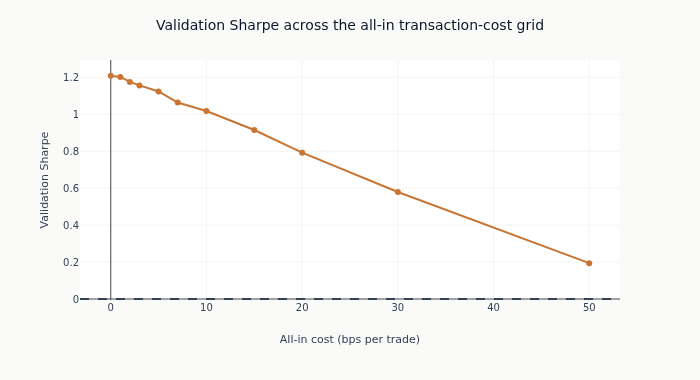

In [14]:
fig = px.line(
    cost_curve.to_pandas(),
    x="total_cost_bps",
    y="sharpe",
    markers=True,
    labels={"total_cost_bps": "All-in cost (bps per trade)", "sharpe": "Validation Sharpe"},
    color_discrete_sequence=[COLORS["copper"]],
)
fig.update_layout(
    title="Validation Sharpe across the all-in transaction-cost grid",
    height=380,
)
fig.add_hline(y=0, line_dash="dash", line_color=COLORS["neutral"])
fig.show()

## The holdout

The research lock is what allows the holdout to be used at all. It records the candidate set, the
selected validation backtest, and the retraining contract - the same specification, differing only
in the cross-validation interval that extends through the holdout period - before any holdout
artifact exists. The lifecycle then admits one evaluation against that lock and refuses a second,
so the holdout cannot become an axis to search over.

The lock and its single evaluation are created by the lifecycle path, not here. This notebook
reads what that path recorded and reports the selected configuration's holdout result beside its
validation result. Where the lifecycle has not yet been locked, the table below is empty and the
validation result above stands on its own.

In [15]:
holdout = holdout_evidence(study)
if holdout.height > 1:
    raise RuntimeError("the lifecycle holds more than one research lock")
if not holdout.is_empty():
    locked = holdout.item(0, "validation_backtest_hash")
    if locked != selected.hash:
        raise RuntimeError(
            f"the research lock was created from backtest {locked}, "
            f"not the configuration this pool selects, {selected.hash}"
        )
    if holdout.item(0, "label") != selected_label:
        raise RuntimeError("the research lock records a different return horizon")

In [16]:
holdout

shape: (0, 0)
┌┐
╞╡
└┘

In [17]:
if holdout.is_empty() or holdout.item(0, "holdout_backtest_hash") is None:
    comparison = pl.DataFrame()
else:
    evaluated = study.backtests.table(include_preview=True).filter(
        pl.col("backtest_hash") == holdout.item(0, "holdout_backtest_hash")
    )
    comparison = pl.concat(
        [
            selected_row.select("label", "sharpe", "max_drawdown", "num_trades").with_columns(
                pl.lit("validation").alias("split")
            ),
            evaluated.select("label", "sharpe", "max_drawdown", "num_trades").with_columns(
                pl.lit("holdout").alias("split")
            ),
        ]
    ).select("split", "label", "sharpe", "max_drawdown", "num_trades")
comparison

shape: (0, 0)
┌┐
╞╡
└┘